# Dimerization model for homoFRET/anisotropy data

**Purpose**
This notebook fits a two-state monomer–dimer equilibrium model to the binned species fraction data from MC4R anisotropy/FLIM measurements. 

Given the total receptor surface concentration and the experimentally derived monomer and dimer fractions per cell, it estimates the dimerization dissociation constant **K_D** via nonlinear least-squares optimization, then quantifies uncertainty through bootstrapping.

**Input**
Tab-delimited txt file with three columns: total receptor concentration (in uM), monomer fraction and dimer fraction

**Physical Model**
The dimerization equilibrium is:
M + M ⇌ D, with K_D = [M]² / [D]
Mass balance for total concentration C_t:

C_t = M + 2D = M + 2M²/K_D

This is solved numerically per data point using scipy.fsolve. The relative monomer and dimer fractions within the labeled pool are then:

f_M,rel = M / (M + 2D)
f_D,rel = 2D / (M + 2D)

Absolute (observable) fractions are scaled by species_total, a factor representing the total fraction of fluorescently labeled receptor that contributes to the FRET/anisotropy signal:

f_M,abs = f_M,rel × species_total
f_D,abs = f_D,rel × species_total

**Workflow**

*Model definition & data loading*
Three functions are defined:
| Function | Role | 
| --- | --- |
| equilibrium_relative_fractions(Ct, Kd) | Solves the mass-balance quadratic numerically for each data point; returns relative monomer/dimer fractions |
| model_predict(concs, Kd, species_total, fit_total) | Scales relative fractions by species_total to yield absolute predicted fractions |
| residuals(params, ...) | Objective function for least_squares; stacks monomer and dimer residuals into a single vector |

*Fitting*
least_squares minimizes the combined monomer + dimer residuals. The optimizer works in log₁₀(K_D) space (bounded between 10⁻⁶ and 10⁶ µM) for numerical stability.
Two modes controlled by the fit_total flag:
| fit_total | Free parameters | Fixed parameters | 
| --- | --- | --- |
|False (default) | K_D only | species_total = 0.38 |
| True | K_D and species_total | — |

The species_total = 0.38 fixed value reflects the known or independently estimated total labeled fraction from the anisotropy experiment.

*Bootstrapping*
500 bootstrap iterations (resampling cells with replacement, fixed seed rng=1 for reproducibility). Each iteration re-runs least_squares from the previously fitted optimum. Outputs:
- Bootstrap mean and std of K_D
- 95% confidence interval of K_D (2.5th–97.5th percentile)
- If fit_total=True: same statistics for species_total
- Histogram of the bootstrap K_D distribution

In [7]:
# This script fits a 2-state
# model (monomer + dimer) to experimental fractional-population data.

import numpy as np
import pandas as pd
from scipy.optimize import least_squares
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

In [8]:
# -----------------------------
# Model definitions
# -----------------------------
# Given total receptor concentration Ct (array), and a dimerization Kd (same units)
# compute the equilibrium monomer (M) and dimer (D) concentrations for the
# *labeled* pool. The routine below returns absolute fractions for monomer and
# dimer that sum to species_total (either fixed or fitted).

def equilibrium_relative_fractions(Ct, Kd):
    """Return relative fractions (fM_rel, fD_rel) that sum to 1 for each Ct.
    These are the fractions *within the labeled pool* (monomer vs dimer)."""
    Ct = np.atleast_1d(Ct)
    fM_rel = np.zeros_like(Ct, dtype=float)
    fD_rel = np.zeros_like(Ct, dtype=float)
    for i, c in enumerate(Ct):
        # Solve mass-balance for monomer concentration M in the labeled pool:
        # Ct_labeled = M + 2*D and D = M^2 / Kd  ->  M + 2*M^2/Kd = Ct_labeled
        # Here, we compute the relative distribution (M and D) for a given Ct_labeled = 1
        # so the absolute scale cancels and we get relative fractions. Equivalent approach:
        # Let x = M/Ct_labeled. Then 1 = x + 2*(Ct_labeled*x)^2/Kd / Ct_labeled -> depends on Ct_labeled.
        # The simplest robust approach is to solve the quadratic for M given Ct_labeled=1.
        # But because Ct_labeled appears in the quadratic, we compute real M by solving the
        # actual equation with Ct_labeled = c (here we treat c as the concentration of interest).
        # Use fsolve with an initial guess.
        def mass_balance(M):
            return M + 2*(M**2)/Kd - c
        # initial guess: assume mostly monomer
        M_guess = min(c, 1e-6 + c/2)
        try:
            M = fsolve(mass_balance, M_guess, xtol=1e-12, maxfev=200)[0]
        except Exception:
            # fallback analytic quadratic solution for M when expressed differently
            M = np.nan
        if M < 0:
            M = 0.0
        D = M**2 / Kd
        total = M + 2*D
        if total <= 0:
            fM_rel[i] = 1.0
            fD_rel[i] = 0.0
        else:
            fM_rel[i] = M/total
            fD_rel[i] = 2*D/total
    return fM_rel, fD_rel


def model_predict(concs, Kd, species_total=0.38, fit_total=False):
    """Return predicted absolute fractions (fM_abs, fD_abs) for each concentration.
    If fit_total is True, species_total is treated as a scale factor applied to the
    relative fractions (and may vary with Ct if you prefer a different model).
    """
    fM_rel, fD_rel = equilibrium_relative_fractions(concs, Kd)
    if fit_total:
        # species_total is expected to be an array the same length as concs (or scalar)
        fM_abs = fM_rel * species_total
        fD_abs = fD_rel * species_total
    else:
        fM_abs = fM_rel * species_total
        fD_abs = fD_rel * species_total
    return fM_abs, fD_abs

# -----------------------------
# Objective / residuals for least_squares
# -----------------------------

def residuals(params, concs, fM_exp, fD_exp, fit_total=False):
    # params: [log10_Kd, species_total] or [log10_Kd]
    log10_Kd = params[0]
    Kd = 10**log10_Kd
    if fit_total:
        species_total = params[1]
    else:
        species_total = 0.38
    fM_pred, fD_pred = model_predict(concs, Kd, species_total=species_total, fit_total=fit_total)
    # stack residuals for monomer and dimer
    res = np.concatenate([fM_pred - fM_exp, fD_pred - fD_exp])
    return res

# -----------------------------
# Example: synthetic data or load your data
# -----------------------------
# If you have your data in a CSV with columns: conc_uM, fM, fD, uncomment the load block
df = pd.read_csv("MC4R-B2.txt", sep='\t')
concs = df['Ct'].values
fM_exp = df['f_monomer'].values
fD_exp = df['f_dimer'].values

df.head()

,Ct,f_dimer,f_monomer
0,0.60,0.06149,0.31851
1,0.54,0.09010,0.28990
2,0.98,0.12036,0.25964
3,1.23,0.13690,0.24310
4,1.21,0.12753,0.25247


In [9]:
# -----------------------------
# Fit: choose whether to fit species_total or keep fixed
# -----------------------------
fit_total = False # set True to let species_total be fitted

if fit_total:
    x0 = [np.log10(20.0), 0.3]
    bounds = ([-6, 0.0], [6, 1.0])
else:
    x0 = [np.log10(20.0)]
    bounds = ([-6], [6])

result = least_squares(residuals, x0, args=(concs, fM_exp, fD_exp, fit_total), bounds=bounds, xtol=1e-12, ftol=1e-12)

fitted_log10Kd = result.x[0]
fitted_Kd = 10**fitted_log10Kd
if fit_total:
    fitted_total = result.x[1]
else:
    fitted_total = 0.38


print(f"Fitted Kd = {fitted_Kd:.3g} (uM)")
print(f"Fitted species_total = {fitted_total:.4g}")

Fitted Kd = 15.3 (uM)
Fitted species_total = 0.38


/tmp/ipykernel_1214155/410382277.py:30: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  M = fsolve(mass_balance, M_guess, xtol=1e-12, maxfev=200)[0]


/tmp/ipykernel_1214155/410382277.py:30: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  M = fsolve(mass_balance, M_guess, xtol=1e-12, maxfev=200)[0]


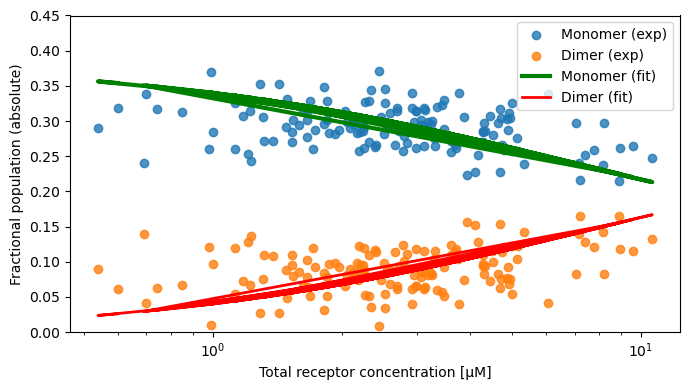

In [10]:
# -----------------------------
# Plot results
# -----------------------------
fM_fit, fD_fit = model_predict(concs, fitted_Kd, species_total=fitted_total)


plt.figure(figsize=(7,4))
plt.scatter(concs, fM_exp, label='Monomer (exp)', alpha=0.8)
plt.scatter(concs, fD_exp, label='Dimer (exp)', alpha=0.8)
plt.plot(concs, fM_fit, color='green', lw=3, label='Monomer (fit)')
plt.plot(concs, fD_fit, color='red', lw=2, label='Dimer (fit)')
plt.xscale('log')
plt.xlabel('Total receptor concentration [\u03BCM]')
plt.ylabel('Fractional population (absolute)')
plt.ylim(0, max(0.45, fitted_total+0.05))
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# -----------------------------
# Save fit results to CSV
# -----------------------------
out_df = pd.DataFrame({'conc_uM': concs, 'fM_exp': fM_exp, 'fD_exp': fD_exp,
'fM_fit': fM_fit, 'fD_fit': fD_fit})
out_df.to_csv('fit_results_mono_dimer_B2.csv', index=False)
print('Saved fit_results_mono_dimer_B2.csv')

Saved fit_results_mono_dimer_B2.csv


/tmp/ipykernel_1214155/410382277.py:30: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  M = fsolve(mass_balance, M_guess, xtol=1e-12, maxfev=200)[0]


Bootstrapping successful runs: 500 / 500
Kd bootstrap mean = 15.28
Kd bootstrap std = 0.8406
Kd 95% CI = [13.72, 17]


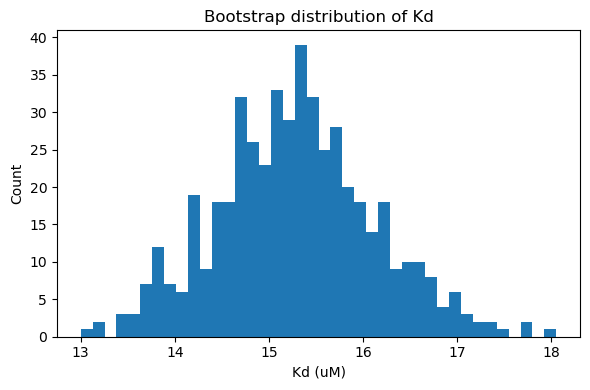

In [12]:
# -----------------------------
# Bootstrapping
# -----------------------------
N_BOOT = 500 # change as needed
boot_Kd = []
boot_total = []


rng = np.random.default_rng(1)
n = len(concs)


for i in range(N_BOOT):
    idx = rng.integers(0, n, n) # resample with replacement
    concs_b = concs[idx]
    fM_b = fM_exp[idx]
    fD_b = fD_exp[idx]


    if fit_total:
        x0 = [np.log10(fitted_Kd), fitted_total]
        bounds = ([-6, 0.0], [6, 1.0])
    else:
        x0 = [np.log10(fitted_Kd)]
        bounds = ([-6], [6])


    try:
        res_b = least_squares(residuals, x0, args=(concs_b, fM_b, fD_b, fit_total),
                              bounds=bounds, xtol=1e-10, ftol=1e-10)
        boot_Kd.append(10**res_b.x[0])
        if fit_total:
            boot_total.append(res_b.x[1])
    except Exception:
        pass

boot_Kd = np.array(boot_Kd)
print(f"Bootstrapping successful runs: {len(boot_Kd)} / {N_BOOT}")
print(f"Kd bootstrap mean = {np.mean(boot_Kd):.4g}")
print(f"Kd bootstrap std = {np.std(boot_Kd):.4g}")
print(f"Kd 95% CI = [{np.percentile(boot_Kd, 2.5):.4g}, {np.percentile(boot_Kd, 97.5):.4g}]")


if fit_total:
    boot_total = np.array(boot_total)
    print(f"species_total bootstrap mean = {np.mean(boot_total):.4g}")
    print(f"species_total 95% CI = [{np.percentile(boot_total, 2.5):.4g}, {np.percentile(boot_total, 97.5):.4g}]")

# Histogram of bootstrap Kd values
plt.figure(figsize=(6,4))
plt.hist(boot_Kd, bins=40)
plt.xlabel('Kd (uM)')
plt.ylabel('Count')
plt.title('Bootstrap distribution of Kd')
plt.tight_layout()
plt.show()
